# FraudGuard — Validation Model Experiment

## Mục tiêu

So sánh công bằng bốn candidate Logistic Regression/XGBoost trên hai feature
set bằng cùng population, temporal split, threshold policy và random seed.

## Quy tắc

- Chỉ sử dụng validation để so sánh và chọn candidate.
- Không dùng test để chỉnh model, feature hoặc threshold.
- Precision tối thiểu là 10%.
- Ưu tiên recall, sau đó PR-AUC, sau đó alert rate.
- Model phức tạp hơn chỉ được chọn khi có cải thiện đủ rõ.

## Giới hạn

Dữ liệu hiện tại nhỏ và có rất ít fraud case. Kết quả chứng minh quy trình
experiment; không phải bằng chứng về hiệu năng production.


## Cách đọc notebook

Bốn candidate được tạo từ hai loại model và hai bộ feature:

| Candidate | Model | Bộ feature |
|---|---|---|
| A | Logistic Regression | Baseline |
| B | XGBoost | Baseline |
| C | Logistic Regression | Balance |
| D | XGBoost | Balance |

Notebook đi theo luồng: **kiểm tra artifact → so sánh metric → phân tích threshold → xem khả năng xếp hạng → giải thích feature → chọn model**. Vì fraud chỉ chiếm khoảng 1.25% validation, **PR-AUC, precision và recall có ý nghĩa hơn accuracy**. ROC-AUC vẫn được báo cáo nhưng có thể trông rất cao trên dữ liệu mất cân bằng.


In [1]:
from __future__ import annotations

import json
import math
import os
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.metrics import average_precision_score, precision_recall_curve

from fraudguard_ml.dataset_loader import load_dataset_splits
from fraudguard_ml.dataset_manifest import load_manifest
from fraudguard_ml.experiment_config import ExperimentConfig

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 120,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
    }
)

CANDIDATE_COLORS = {
    "A": "#4C78A8",
    "B": "#F58518",
    "C": "#54A24B",
    "D": "#E45756",
}

In [2]:
def find_repository_root(start: Path) -> Path:
    """Find the nearest parent containing pyproject.toml and the ML package."""

    for candidate in (start, *start.parents):
        if (
            (candidate / "pyproject.toml").is_file()
            and (candidate / "ml" / "src" / "fraudguard_ml").is_dir()
        ):
            return candidate
    raise FileNotFoundError(
        "Cannot find repository root. Start Jupyter inside ML_Fraud_Banking."
    )


REPOSITORY_ROOT = find_repository_root(Path.cwd().resolve())
REPOSITORY_ROOT

PosixPath('/home/phongthanh/ML_Fraud_Banking')

## 1. Khóa run và xác định phạm vi so sánh

Phần này cố định `RUN_ID`, khai báo đúng bốn candidate và kiểm tra đủ artifact đầu vào. Khóa run giúp kết quả có thể tái lập và tránh vô tình trộn model, dữ liệu hoặc metric từ các lần chạy khác nhau.


In [3]:
RUN_ID = os.getenv("FRAUDGUARD_EXPERIMENT_RUN_ID", "20260825T082223Z")

RUN_ROOT = (
    REPOSITORY_ROOT
    / "airflow_ml_artifacts"
    / "model_experiments"
    / RUN_ID
)
REPORT_ROOT = (
    REPOSITORY_ROOT
    / "reports"
    / "model_experiments"
    / RUN_ID
)
REPORT_ROOT.mkdir(parents=True, exist_ok=True)

CANDIDATES: dict[str, dict[str, str]] = {
    "A": {
        "model": "logistic_regression",
        "model_label": "Logistic Regression",
        "feature_set": "baseline",
        "label": "A · Logistic · Baseline",
    },
    "B": {
        "model": "xgboost",
        "model_label": "XGBoost",
        "feature_set": "baseline",
        "label": "B · XGBoost · Baseline",
    },
    "C": {
        "model": "logistic_regression",
        "model_label": "Logistic Regression",
        "feature_set": "balance",
        "label": "C · Logistic · Balance",
    },
    "D": {
        "model": "xgboost",
        "model_label": "XGBoost",
        "feature_set": "balance",
        "label": "D · XGBoost · Balance",
    },
}

assert RUN_ROOT.is_dir(), f"Run directory does not exist: {RUN_ROOT}"
print(f"Analyzing RUN_ID={RUN_ID}")
print(f"Artifacts: {RUN_ROOT}")
print(f"Reports:   {REPORT_ROOT}")

Analyzing RUN_ID=20260825T082223Z
Artifacts: /home/phongthanh/ML_Fraud_Banking/airflow_ml_artifacts/model_experiments/20260825T082223Z
Reports:   /home/phongthanh/ML_Fraud_Banking/reports/model_experiments/20260825T082223Z


In [4]:
def candidate_paths(candidate_id: str) -> dict[str, Path]:
    candidate_root = RUN_ROOT / "candidates" / candidate_id
    return {
        "metrics": candidate_root / "model" / "validation_metrics.json",
        "manifest": candidate_root / "experiment" / "dataset_manifest.json",
        "snapshot": candidate_root / "experiment" / "data.parquet",
        "bundle": candidate_root / "model" / "model_bundle.joblib",
    }


ARTIFACT_PATHS = {
    candidate_id: candidate_paths(candidate_id)
    for candidate_id in CANDIDATES
}

missing_artifacts = [
    path
    for paths in ARTIFACT_PATHS.values()
    for path in paths.values()
    if not path.is_file()
]
if missing_artifacts:
    formatted = "\n".join(f"- {path}" for path in missing_artifacts)
    raise FileNotFoundError(f"Required Phase-4 artifacts are missing:\n{formatted}")

pd.DataFrame(
    [
        {
            "candidate_id": candidate_id,
            **{name: str(path.relative_to(REPOSITORY_ROOT)) for name, path in paths.items()},
        }
        for candidate_id, paths in ARTIFACT_PATHS.items()
    ]
)

,candidate_id,metrics,manifest,snapshot,bundle
0,A,airflow_ml_artifacts/model_experiments/2026082...,airflow_ml_artifacts/model_experiments/2026082...,airflow_ml_artifacts/model_experiments/2026082...,airflow_ml_artifacts/model_experiments/2026082...
1,B,airflow_ml_artifacts/model_experiments/2026082...,airflow_ml_artifacts/model_experiments/2026082...,airflow_ml_artifacts/model_experiments/2026082...,airflow_ml_artifacts/model_experiments/2026082...
2,C,airflow_ml_artifacts/model_experiments/2026082...,airflow_ml_artifacts/model_experiments/2026082...,airflow_ml_artifacts/model_experiments/2026082...,airflow_ml_artifacts/model_experiments/2026082...
3,D,airflow_ml_artifacts/model_experiments/2026082...,airflow_ml_artifacts/model_experiments/2026082...,airflow_ml_artifacts/model_experiments/2026082...,airflow_ml_artifacts/model_experiments/2026082...


In [5]:
def load_json_object(path: Path) -> dict[str, Any]:
    """Load a JSON object and fail with a path-specific error."""

    try:
        payload = json.loads(path.read_text(encoding="utf-8"))
    except (OSError, json.JSONDecodeError) as exc:
        raise ValueError(f"Cannot read valid JSON: {path}") from exc
    if not isinstance(payload, dict):
        raise TypeError(f"JSON root must be an object: {path}")
    return payload

raw_metrics: dict[str, dict[str, Any]] = {
    candidate_id: load_json_object(paths["metrics"])
    for candidate_id, paths in ARTIFACT_PATHS.items()
}

assert set(raw_metrics) == {"A", "B", "C", "D"}
print("Loaded 4/4 validation_metrics.json files")

Loaded 4/4 validation_metrics.json files


## 2. Chuẩn hóa metric và kiểm tra tính công bằng

Các metric trong bốn file JSON được đưa về cùng một bảng. Các assertion kế tiếp xác nhận mọi candidate dùng chung population (`population_fingerprint`), cùng 3,723 dòng train và 24 fraud case trong train. Nhờ đó, khác biệt metric chủ yếu phản ánh lựa chọn model/feature thay vì khác biệt dữ liệu đầu vào.

> Đây là điều kiện cần cho so sánh công bằng, nhưng chưa loại bỏ độ bất định do validation chỉ có 14 fraud case.


In [6]:
def require_finite_number(
    payload: dict[str, Any],
    key: str,
    *,
    candidate_id: str,
) -> float:
    value = payload.get(key)
    if isinstance(value, bool) or not isinstance(value, (int, float)):
        raise TypeError(f"Candidate {candidate_id}: {key!r} must be numeric")
    number = float(value)
    if not math.isfinite(number):
        raise ValueError(f"Candidate {candidate_id}: {key!r} must be finite")
    return number


def metrics_row(
    candidate_id: str,
    metrics: dict[str, Any],
) -> dict[str, Any]:
    expected = CANDIDATES[candidate_id]
    metadata = metrics.get("model_metadata")
    if not isinstance(metadata, dict):
        raise TypeError(f"Candidate {candidate_id}: model_metadata must be an object")

    model_kind = metadata.get("model_kind")
    if model_kind != expected["model"]:
        raise ValueError(
            f"Candidate {candidate_id}: expected {expected['model']!r}, "
            f"got {model_kind!r}"
        )

    threshold_selection = metrics.get("threshold_selection")
    if not isinstance(threshold_selection, dict):
        raise TypeError(
            f"Candidate {candidate_id}: threshold_selection must be an object"
        )

    return {
        "candidate_id": candidate_id,
        "candidate_label": expected["label"],
        "model": expected["model"],
        "model_label": expected["model_label"],
        "feature_set": expected["feature_set"],
        "population_fingerprint": metrics.get("population_fingerprint"),
        "train_rows": int(
            require_finite_number(metrics, "train_rows", candidate_id=candidate_id)
        ),
        "train_fraud": int(
            require_finite_number(metrics, "train_fraud", candidate_id=candidate_id)
        ),
        "best_iteration": metadata.get("best_iteration"),
        "scale_pos_weight": metadata.get("scale_pos_weight"),
        "threshold": require_finite_number(
            metrics, "threshold", candidate_id=candidate_id
        ),
        "threshold_strategy": threshold_selection.get("strategy_result"),
        "validation_pr_auc": require_finite_number(
            metrics, "pr_auc", candidate_id=candidate_id
        ),
        "validation_roc_auc": require_finite_number(
            metrics, "roc_auc", candidate_id=candidate_id
        ),
        "validation_precision": require_finite_number(
            metrics, "precision", candidate_id=candidate_id
        ),
        "validation_recall": require_finite_number(
            metrics, "recall", candidate_id=candidate_id
        ),
        "validation_f1": require_finite_number(
            metrics, "f1", candidate_id=candidate_id
        ),
        "validation_alert_rate": require_finite_number(
            metrics, "alert_rate", candidate_id=candidate_id
        ),
        "training_seconds": require_finite_number(
            metrics, "training_seconds", candidate_id=candidate_id
        ),
    }


comparison = pd.DataFrame(
    [metrics_row(candidate_id, raw_metrics[candidate_id]) for candidate_id in CANDIDATES]
).sort_values("candidate_id", ignore_index=True)

comparison


,candidate_id,candidate_label,model,model_label,feature_set,population_fingerprint,train_rows,train_fraud,best_iteration,scale_pos_weight,threshold,threshold_strategy,validation_pr_auc,validation_roc_auc,validation_precision,validation_recall,validation_f1,validation_alert_rate,training_seconds
0,A,A · Logistic · Baseline,logistic_regression,Logistic Regression,baseline,xor64:3f1a400c9204dedc,3723,24,NaN,NaN,0.0740,max_recall_at_min_precision,0.5661,0.9323,0.1000,0.9286,0.1806,0.1164,0.1243
1,B,B · XGBoost · Baseline,xgboost,XGBoost,baseline,xor64:3f1a400c9204dedc,3723,24,159.0000,154.1250,0.0091,max_recall_at_min_precision,0.7560,0.9934,0.1000,1.0000,0.1818,0.1253,0.2190
2,C,C · Logistic · Balance,logistic_regression,Logistic Regression,balance,xor64:3f1a400c9204dedc,3723,24,NaN,NaN,0.0083,max_recall_at_min_precision,0.8484,0.9986,0.1000,1.0000,0.1818,0.1253,0.1464
3,D,D · XGBoost · Balance,xgboost,XGBoost,balance,xor64:3f1a400c9204dedc,3723,24,20.0000,154.1250,0.2171,max_recall_at_min_precision,0.9556,0.9985,0.1014,1.0000,0.1842,0.1235,0.1886


In [7]:
PROBABILITY_METRICS = [
    "threshold",
    "validation_pr_auc",
    "validation_roc_auc",
    "validation_precision",
    "validation_recall",
    "validation_f1",
    "validation_alert_rate",
]

assert comparison["candidate_id"].tolist() == ["A", "B", "C", "D"]
assert comparison["population_fingerprint"].nunique() == 1, (
    "Candidates do not share one population fingerprint"
)
assert comparison["train_rows"].nunique() == 1, "Train row counts differ"
assert comparison["train_fraud"].nunique() == 1, "Train fraud counts differ"
assert (comparison["training_seconds"] >= 0).all()
assert comparison[PROBABILITY_METRICS].apply(
    lambda series: series.between(0.0, 1.0).all()
).all()
assert set(comparison["threshold_strategy"]) <= {
    "max_recall_at_min_precision",
    "fallback_max_f1",
}

for candidate_id in ("A", "C"):
    row = comparison.set_index("candidate_id").loc[candidate_id]
    assert pd.isna(row["best_iteration"])
    assert pd.isna(row["scale_pos_weight"])

for candidate_id in ("B", "D"):
    row = comparison.set_index("candidate_id").loc[candidate_id]
    assert pd.notna(row["best_iteration"])
    assert pd.notna(row["scale_pos_weight"])

print("Metric invariants passed")
print("Population:", comparison["population_fingerprint"].iloc[0])


Metric invariants passed
Population: xor64:3f1a400c9204dedc


## 3. Bảng so sánh validation

Ý nghĩa các metric chính:

- **PR-AUC**: chất lượng xếp hạng fraud trên toàn bộ threshold; càng cao càng tốt và phù hợp với bài toán mất cân bằng.
- **Recall**: tỷ lệ fraud thực tế được phát hiện.
- **Precision**: tỷ lệ cảnh báo thực sự là fraud. Precision 10% tương đương trung bình khoảng 1 fraud trong 10 cảnh báo.
- **Alert rate**: tỷ lệ giao dịch bị đẩy sang luồng cảnh báo; đại diện gần đúng cho tải vận hành.
- **Threshold**: ngưỡng xác suất riêng của từng model. Không nên so sánh trực tiếp trị số threshold giữa các model vì xác suất có thể được hiệu chỉnh khác nhau.


In [8]:
DISPLAY_COLUMNS = [
    "candidate_id",
    "model_label",
    "feature_set",
    "validation_pr_auc",
    "validation_roc_auc",
    "validation_precision",
    "validation_recall",
    "validation_f1",
    "validation_alert_rate",
    "threshold",
    "best_iteration",
    "training_seconds",
]

display(
    comparison[DISPLAY_COLUMNS].style.format(
        {
            "validation_pr_auc": "{:.4f}",
            "validation_roc_auc": "{:.4f}",
            "validation_precision": "{:.2%}",
            "validation_recall": "{:.2%}",
            "validation_f1": "{:.4f}",
            "validation_alert_rate": "{:.2%}",
            "threshold": "{:.6f}",
            "training_seconds": "{:.4f}",
        }
    ).background_gradient(
        subset=["validation_pr_auc", "validation_recall"],
        cmap="YlGn",
    )
)

comparison.to_csv(REPORT_ROOT / "model_comparison.csv", index=False)


,candidate_id,model_label,feature_set,validation_pr_auc,validation_roc_auc,validation_precision,validation_recall,validation_f1,validation_alert_rate,threshold,best_iteration,training_seconds
0,A,Logistic Regression,baseline,0.5661,0.9323,10.00%,92.86%,0.1806,11.64%,0.073980,nan,0.1243
1,B,XGBoost,baseline,0.7560,0.9934,10.00%,100.00%,0.1818,12.53%,0.009113,159.000000,0.2190
2,C,Logistic Regression,balance,0.8484,0.9986,10.00%,100.00%,0.1818,12.53%,0.008280,nan,0.1464
3,D,XGBoost,balance,0.9556,0.9985,10.14%,100.00%,0.1842,12.35%,0.217136,20.000000,0.1886


### Nhận xét từ bảng

- D đứng đầu về PR-AUC (**0.9556**), tiếp theo là C (**0.8484**), B (**0.7560**) và A (**0.5661**).
- Khi giữ nguyên loại model, feature `balance` tăng PR-AUC rõ rệt: A → C tăng **0.2823**, B → D tăng **0.1996**. Đây là tín hiệu mạnh rằng các feature mô tả biến động/sai lệch số dư mang thêm thông tin phát hiện fraud.
- ROC-AUC của C và D đều xấp xỉ **0.999**, gần như không phân biệt được hai candidate; PR-AUC cho thấy rõ hơn lợi thế của D trên lớp fraud hiếm.
- F1 của cả bốn model chỉ quanh **0.18** vì threshold policy ưu tiên recall và chỉ yêu cầu precision tối thiểu 10%; F1 thấp ở đây không mâu thuẫn với PR-AUC cao.

## 4. So sánh metric xếp hạng

Biểu đồ sau đặt PR-AUC, ROC-AUC và F1 cạnh nhau. Cần ưu tiên đọc PR-AUC; ROC-AUC được dùng như metric bổ sung, còn F1 phản ánh đúng một operating point đã chọn.


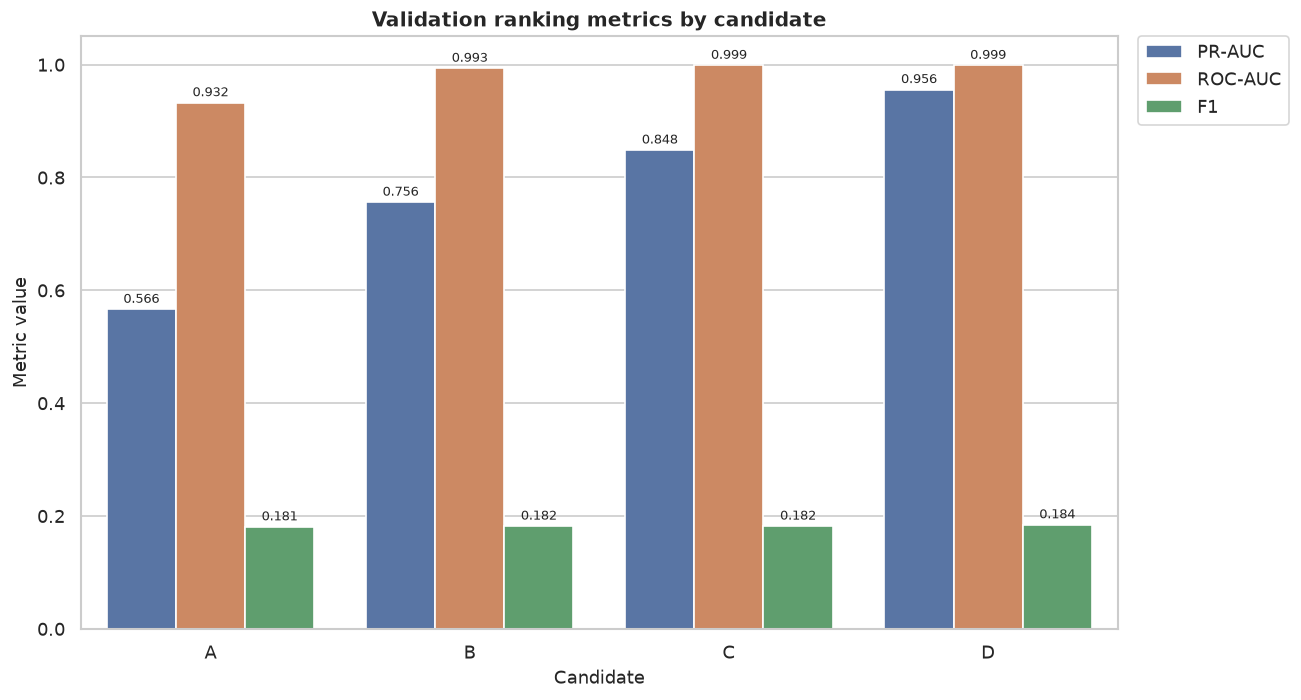

In [9]:
metric_overview = comparison.melt(
    id_vars=["candidate_id", "candidate_label"],
    value_vars=[
        "validation_pr_auc",
        "validation_roc_auc",
        "validation_f1",
    ],
    var_name="metric",
    value_name="value",
)

metric_labels = {
    "validation_pr_auc": "PR-AUC",
    "validation_roc_auc": "ROC-AUC",
    "validation_f1": "F1",
}
metric_overview["metric"] = metric_overview["metric"].map(metric_labels)
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=metric_overview,
    x="candidate_id",
    y="value",
    hue="metric",
    ax=ax,
)
ax.set(
    title="Validation ranking metrics by candidate",
    xlabel="Candidate",
    ylabel="Metric value",
    ylim=(0.0, 1.05),
)

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax.bar_label(ax.containers[0], fmt="%.3f", padding=2, fontsize=8)
ax.bar_label(ax.containers[1], fmt="%.3f", padding=2, fontsize=8)
ax.bar_label(ax.containers[2], fmt="%.3f", padding=2, fontsize=8)
fig.tight_layout()
fig.savefig(REPORT_ROOT / "validation_metric_overview.png", bbox_inches="tight")
plt.show()


### Insight từ biểu đồ ranking metric

Xu hướng PR-AUC tăng đều từ A đến D, trong khi F1 gần như phẳng. Điều này cho thấy khác biệt chính nằm ở **khả năng sắp xếp giao dịch fraud lên trên non-fraud trên toàn dải threshold**, chứ chưa được thể hiện hết tại threshold vận hành hiện tại. D là candidate mạnh nhất theo tiêu chí ranking; feature engineering `balance` cũng tạo lợi ích nhất quán cho cả Logistic Regression lẫn XGBoost.

## 5. Operating point tại threshold đã chọn

Biểu đồ kế tiếp trả lời câu hỏi vận hành: tại threshold được chọn, model bắt được bao nhiêu fraud, cảnh báo chính xác đến đâu và tạo ra bao nhiêu alert. Đường đứt nét là ràng buộc precision tối thiểu 10%.


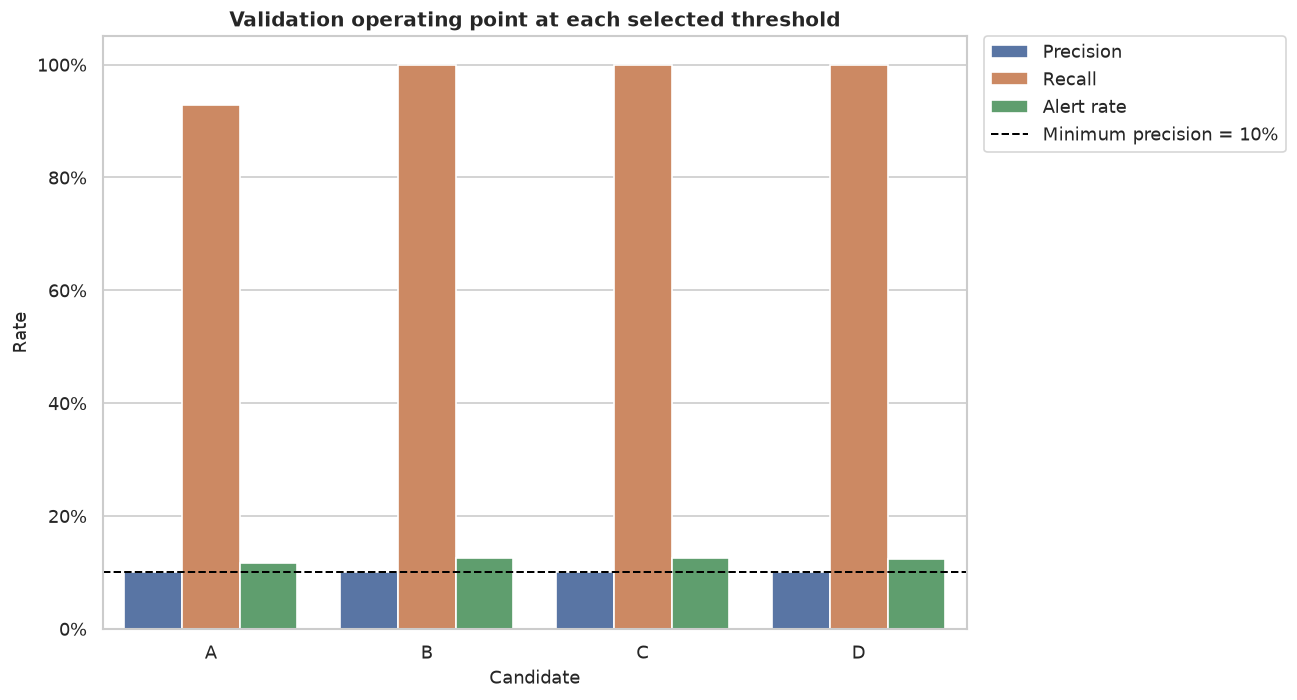

In [10]:
threshold_metrics = comparison.melt(
    id_vars=["candidate_id", "candidate_label"],
    value_vars=[
        "validation_precision",
        "validation_recall",
        "validation_alert_rate",
    ],
    var_name="metric",
    value_name="value",
)

threshold_metric_labels = {
    "validation_precision": "Precision",
    "validation_recall": "Recall",
    "validation_alert_rate": "Alert rate",
}
threshold_metrics["metric"] = threshold_metrics["metric"].map(
    threshold_metric_labels
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=threshold_metrics,
    x="candidate_id",
    y="value",
    hue="metric",
    ax=ax,
)
ax.axhline(
    0.10,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="Minimum precision = 10%",
)
ax.set(
    title="Validation operating point at each selected threshold",
    xlabel="Candidate",
    ylabel="Rate",
    ylim=(0.0, 1.05),
)
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.legend(title="Metric / constraint", loc="upper center")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
fig.tight_layout()
fig.savefig(REPORT_ROOT / "validation_threshold_metrics.png", bbox_inches="tight")
plt.show()


### Insight từ biểu đồ threshold

- Cả bốn candidate đều vừa đạt ràng buộc precision ≥ 10%. B, C và D đạt recall **100%**, tức bắt đủ **14/14 fraud** trong validation; A đạt 92.86%, tương ứng bỏ sót **1 fraud**.
- D tạo 138 cảnh báo gồm 14 true positive và 124 false positive, tương ứng precision **10.14%** và alert rate **12.35%**. So với B/C, D giữ nguyên recall nhưng giảm 2 false positive (alert rate từ 12.53% xuống 12.35%).
- A có alert rate thấp nhất (11.64%) nhưng lợi ích tải vận hành nhỏ đi kèm một false negative. Theo ưu tiên nghiệp vụ hiện tại, đánh đổi này không được chấp nhận.
- Threshold policy đang rất thiên về recall: để bắt fraud cuối cùng, hệ thống chấp nhận khoảng 9 cảnh báo sai cho mỗi cảnh báo đúng. Trước production cần xác nhận đội review có đủ năng lực xử lý khoảng 12.4% tổng giao dịch hay không.

## 6. Tái tạo xác suất validation

Để vẽ đầy đủ Precision–Recall curve, notebook tải model bundle và snapshot đã khóa, sau đó tái tạo xác suất trên validation. PR-AUC tái tạo phải khớp tuyệt đối với JSON; bước này kiểm tra artifact và báo cáo không bị lệch nhau, đồng thời **không huấn luyện lại model**.


In [11]:
manifests = {
    candidate_id: load_manifest(paths["manifest"])
    for candidate_id, paths in ARTIFACT_PATHS.items()
}

def load_validation_artifacts(
    candidate_id: str,
) -> tuple[dict[str, Any], Any, np.ndarray]:
    paths = ARTIFACT_PATHS[candidate_id]
    bundle = joblib.load(paths["bundle"])
    if not isinstance(bundle, dict):
        raise TypeError(f"Candidate {candidate_id}: model bundle must be a dict")

    config = ExperimentConfig.model_validate(bundle["config"])
    manifest = manifests[candidate_id]
    splits = load_dataset_splits(
        snapshot_path=paths["snapshot"],
        manifest=manifest,
        config=config,
    )

    model = bundle["model"]
    probability = np.asarray(
        model.predict_proba(splits.validation.features)[:, 1],
        dtype=np.float64,
    )
    target = splits.validation.target.to_numpy(dtype=np.uint8)

    if probability.shape != target.shape:
        raise ValueError(f"Candidate {candidate_id}: prediction shape mismatch")
    if not np.isfinite(probability).all():
        raise ValueError(f"Candidate {candidate_id}: non-finite probabilities")
    if ((probability < 0.0) | (probability > 1.0)).any():
        raise ValueError(f"Candidate {candidate_id}: probabilities outside [0, 1]")

    expected_pr_auc = float(raw_metrics[candidate_id]["pr_auc"])
    observed_pr_auc = float(average_precision_score(target, probability))
    if not math.isclose(observed_pr_auc, expected_pr_auc, abs_tol=1e-12):
        raise ValueError(
            f"Candidate {candidate_id}: reproduced PR-AUC {observed_pr_auc} "
            f"does not match JSON {expected_pr_auc}"
        )

    return bundle, splits.validation, probability


loaded_validation = {
    candidate_id: load_validation_artifacts(candidate_id)
    for candidate_id in CANDIDATES
}

print("Reproduced validation probabilities and PR-AUC for 4/4 candidates")


Reproduced validation probabilities and PR-AUC for 4/4 candidates


### Cách đọc Precision–Recall curve

Một đường cong nằm cao hơn thể hiện precision tốt hơn tại cùng mức recall. Đường chấm ngang là prevalence 1.253% — mức precision của một bộ xếp hạng ngẫu nhiên. Dấu chấm trên mỗi đường là operating point được threshold policy chọn, không phải toàn bộ khả năng của model.


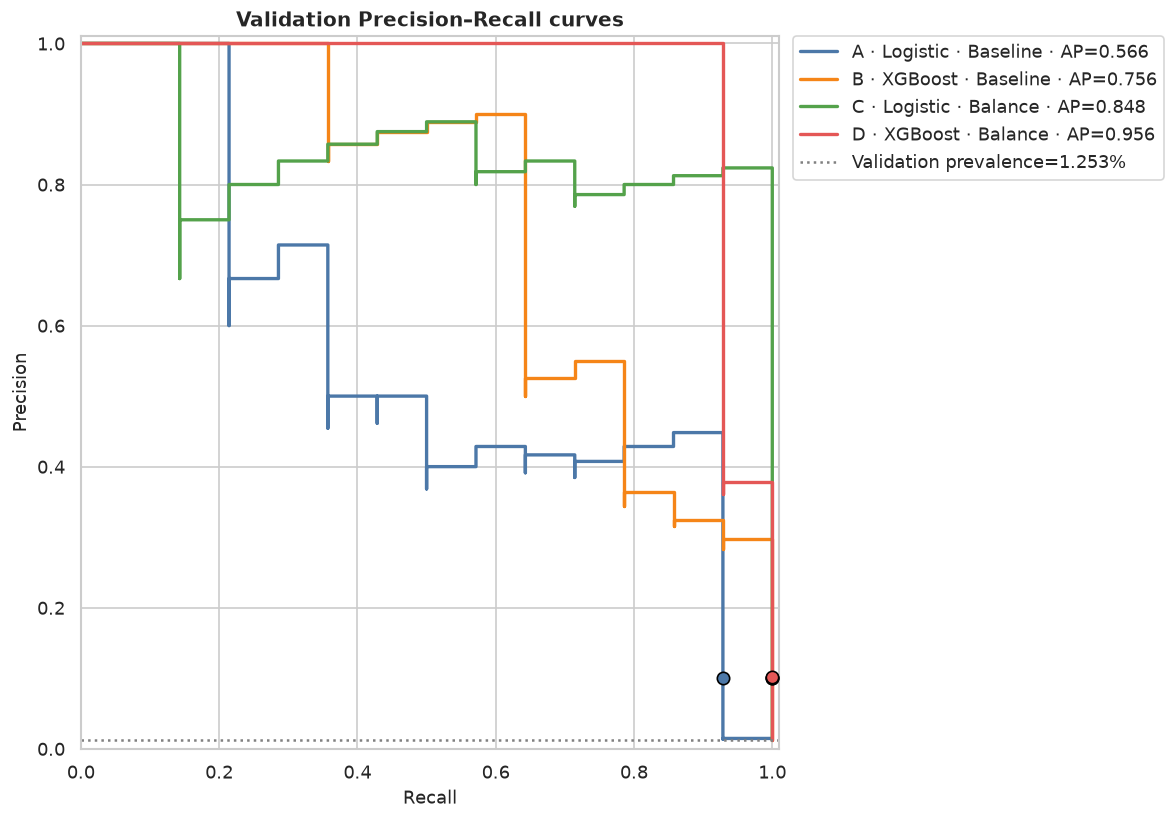

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))

validation_prevalence: float | None = None
for candidate_id, (_, validation_split, probability) in loaded_validation.items():
    target = validation_split.target.to_numpy(dtype=np.uint8)
    precision, recall, _ = precision_recall_curve(target, probability)
    prevalence = float(target.mean())

    if validation_prevalence is None:
        validation_prevalence = prevalence
    elif not math.isclose(validation_prevalence, prevalence, abs_tol=1e-15):
        raise ValueError("Validation prevalence differs across candidates")

    pr_auc = float(raw_metrics[candidate_id]["pr_auc"])
    ax.step(
        recall,
        precision,
        where="post",
        color=CANDIDATE_COLORS[candidate_id],
        linewidth=2,
        label=f"{CANDIDATES[candidate_id]['label']} · AP={pr_auc:.3f}",
    )
    ax.scatter(
        raw_metrics[candidate_id]["recall"],
        raw_metrics[candidate_id]["precision"],
        color=CANDIDATE_COLORS[candidate_id],
        edgecolor="black",
        s=55,
        zorder=3,
    )

assert validation_prevalence is not None
ax.axhline(
    validation_prevalence,
    color="gray",
    linestyle=":",
    linewidth=1.5,
    label=f"Validation prevalence={validation_prevalence:.3%}",
)
ax.set(
    title="Validation Precision–Recall curves",
    xlabel="Recall",
    ylabel="Precision",
    xlim=(0.0, 1.01),
    ylim=(0.0, 1.01),
)
ax.legend(loc="upper right", fontsize=8)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
fig.tight_layout()
fig.savefig(REPORT_ROOT / "validation_pr_curve.png", bbox_inches="tight")
plt.show()


### Insight từ Precision–Recall curve

- Đường D nằm trên các candidate còn lại ở phần lớn miền recall và có AP **0.956**. Đáng chú ý, D duy trì precision rất cao đến khoảng recall 93%; điều này cho phép chọn một operating point bảo thủ hơn nếu doanh nghiệp muốn giảm false positive.
- C là phương án tuyến tính tốt nhất (AP **0.848**) và vượt B dù B dùng XGBoost. Điều này củng cố kết luận rằng feature `balance` quan trọng hơn chỉ riêng việc tăng độ phức tạp model.
- Các đường có dạng bậc thang lớn vì validation chỉ có **14 fraud**: mỗi fraud chiếm khoảng 7.14 điểm phần trăm recall. Vì vậy chênh lệch quan sát được có thể biến động mạnh; cần đánh giá thêm trên nhiều dữ liệu theo thời gian.
- Các operating point đều nằm gần precision 10% do rule tối đa hóa recall dưới ràng buộc tối thiểu. Đây là quyết định policy, không phải giới hạn cố định của model.

## 7. Feature importance của XGBoost

Hai panel so sánh 12 feature quan trọng nhất của B và D. Importance cho biết feature được cây sử dụng nhiều/hữu ích đến mức nào trong model, nhưng **không cho biết chiều tác động và không chứng minh quan hệ nhân quả**. Feature tương quan cũng có thể chia sẻ hoặc thay thế importance của nhau.


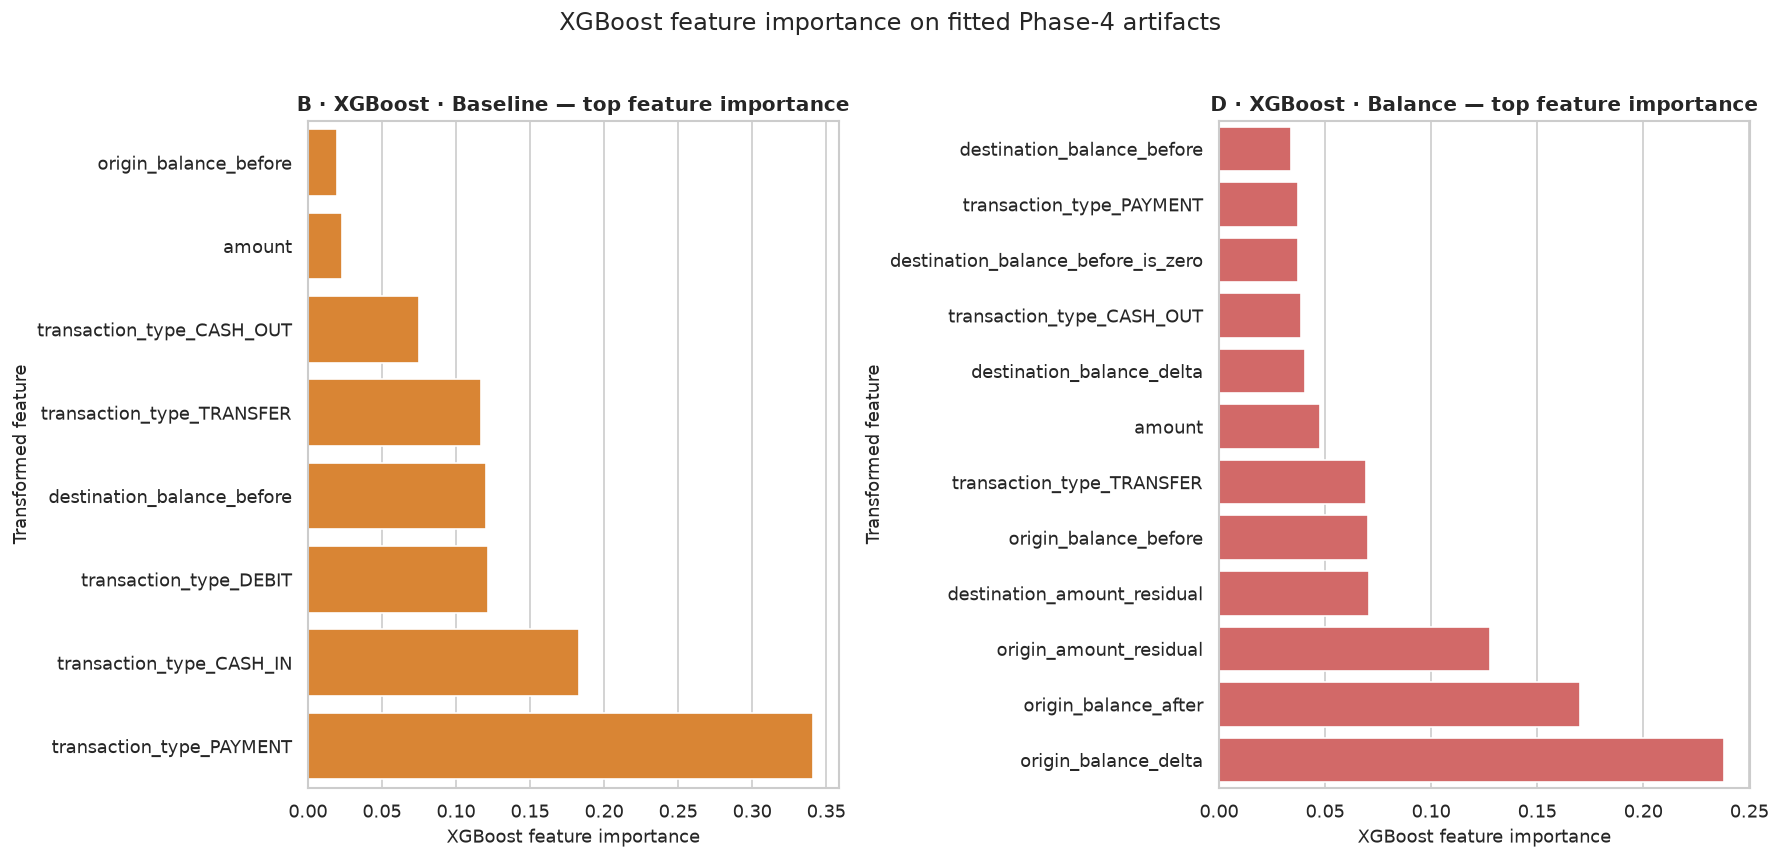

In [ ]:
def clean_transformed_feature_name(name: str) -> str:
    """Remove ColumnTransformer prefixes while preserving category names."""

    return name.split("__", maxsplit=1)[-1]

def xgboost_importance(candidate_id: str) -> pd.DataFrame:
    bundle, _, _ = loaded_validation[candidate_id]
    fitted_model = bundle["model"]
    feature_names = fitted_model.preprocessor.get_feature_names_out()
    importance = np.asarray(
        fitted_model.estimator.feature_importances_,
        dtype=np.float64,
    )
    if len(feature_names) != len(importance):
        raise ValueError(f"Candidate {candidate_id}: importance shape mismatch")

    return pd.DataFrame(
        {
            "candidate_id": candidate_id,
            "feature": [
                clean_transformed_feature_name(name) for name in feature_names
            ],
            "importance": importance,
        }
    ).sort_values("importance", ascending=False, ignore_index=True)

xgboost_importances = pd.concat(
    [xgboost_importance("B"), xgboost_importance("D")]
)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, candidate_id in zip(axes, ("B", "D"), strict=True):
    plot_data = (
        xgboost_importances.query("candidate_id == @candidate_id")
        .nlargest(12, "importance")
        .sort_values("importance")
    )
    sns.barplot(
        data=plot_data,
        x="importance",
        y="feature",
        color=CANDIDATE_COLORS[candidate_id],
        ax=ax,
    )
    ax.set(
        title=f"{CANDIDATES[candidate_id]['label']} — top feature importance",
        xlabel="XGBoost feature importance",
        ylabel="Transformed feature",
    )
    
fig.suptitle("XGBoost feature importance on fitted Phase-4 artifacts", y=1.02)
fig.tight_layout()
fig.savefig(REPORT_ROOT / "feature_importance.png", bbox_inches="tight")
plt.show()

### Insight từ XGBoost feature importance

- Với B (baseline), model phụ thuộc mạnh vào `transaction_type_PAYMENT` (~0.34) và `transaction_type_CASH_IN` (~0.18). Importance cao của một category không có nghĩa category đó làm tăng fraud; nó cũng có thể giúp cây nhận diện giao dịch ít rủi ro.
- Với D (balance), `origin_balance_delta` (~0.24), `origin_balance_after` (~0.17) và `origin_amount_residual` (~0.13) trở thành ba tín hiệu nổi bật. Model chuyển trọng tâm từ loại giao dịch sang **tính nhất quán của dòng tiền và số dư**.
- Sự thay đổi cấu trúc importance phù hợp với mức tăng PR-AUC của B → D: các feature balance không chỉ xuất hiện trong model mà còn chiếm các vị trí quan trọng nhất. Đây là bằng chứng gợi ý hữu ích, nhưng để giải thích từng prediction nên bổ sung SHAP/permutation importance trên tập holdout lớn hơn.

## 8. Hệ số của Logistic Regression

Màu xanh là hệ số dương (liên hệ với log-odds fraud cao hơn), màu đỏ là hệ số âm. Độ lớn tuyệt đối thể hiện mức ảnh hưởng trong model sau preprocessing. Diễn giải chỉ là mối liên hệ có điều kiện; không nên xem hệ số là tác động nhân quả, và cần thận trọng khi so độ lớn giữa feature số đã chuẩn hóa với biến one-hot.


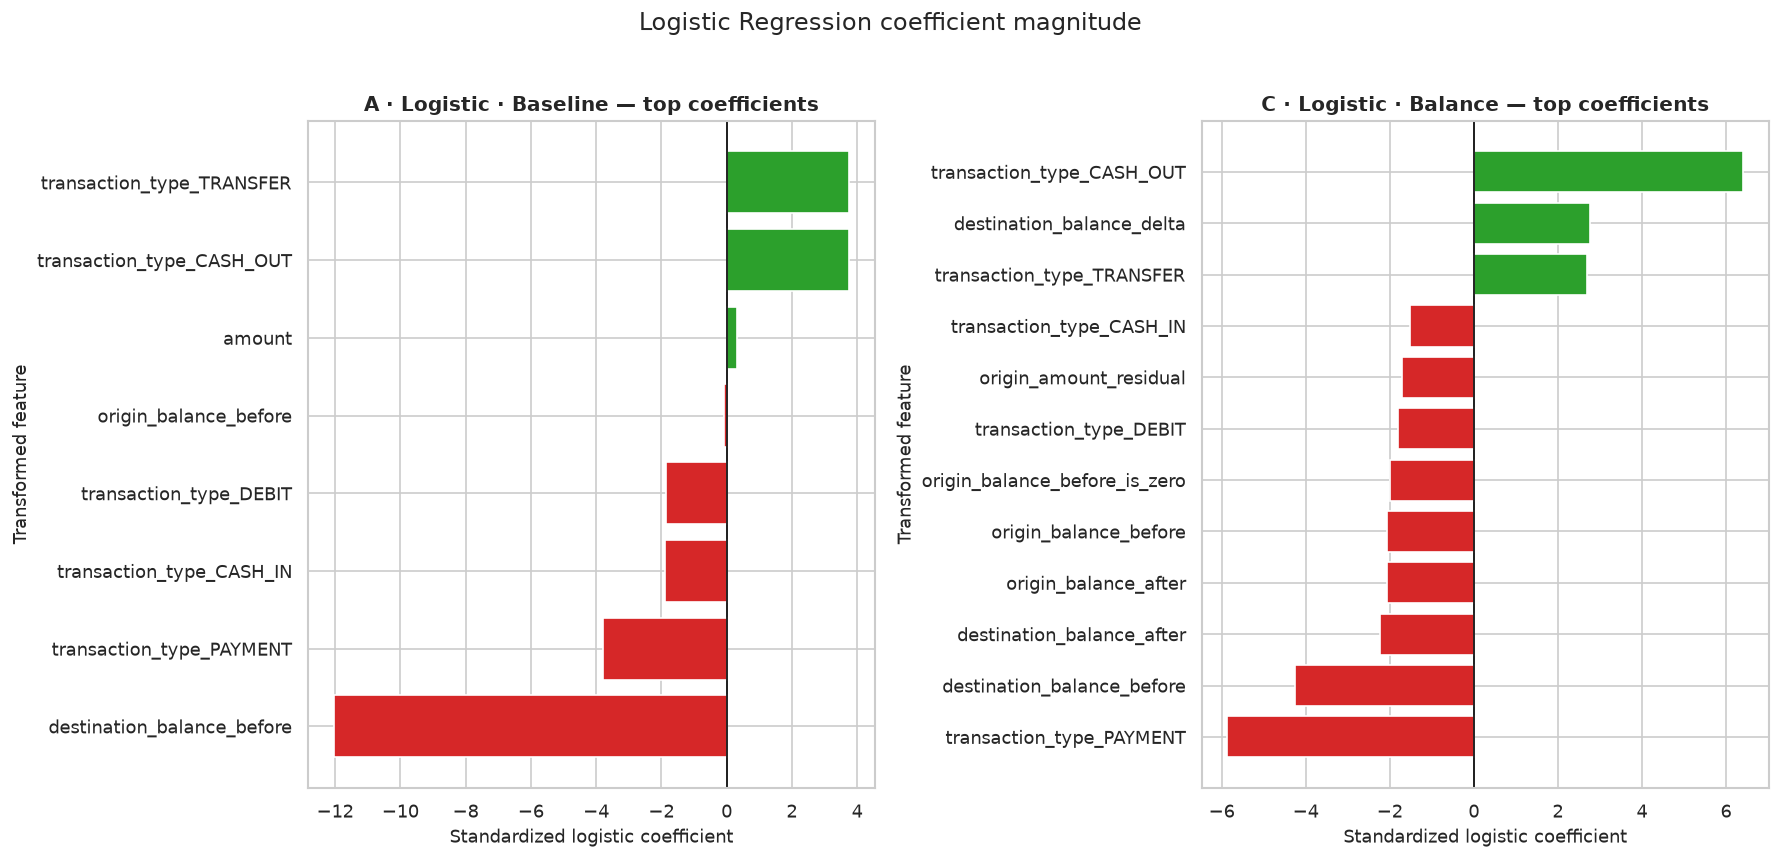

In [36]:
def logistic_coefficients(candidate_id: str) -> pd.DataFrame:
    bundle, _, _ = loaded_validation[candidate_id]
    fitted_model = bundle["model"]
    feature_names = fitted_model.preprocessor.get_feature_names_out()
    coefficient = np.asarray(fitted_model.estimator.coef_[0], dtype=np.float64)
    if len(feature_names) != len(coefficient):
        raise ValueError(f"Candidate {candidate_id}: coefficient shape mismatch")

    return pd.DataFrame(
        {
            "candidate_id": candidate_id,
            "feature": [
                clean_transformed_feature_name(name) for name in feature_names
            ],
            "coefficient": coefficient,
            "absolute_coefficient": np.abs(coefficient),
        }
    ).sort_values("absolute_coefficient", ascending=False, ignore_index=True)


logistic_coefficients_frame = pd.concat(
    [logistic_coefficients("A"), logistic_coefficients("C")],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, candidate_id in zip(axes, ("A", "C"), strict=True):
    plot_data = (
        logistic_coefficients_frame.query("candidate_id == @candidate_id")
        .nlargest(12, "absolute_coefficient")
        .sort_values("coefficient")
    )
    colors = ["#D62728" if value < 0 else "#2CA02C" for value in plot_data["coefficient"]]
    ax.barh(plot_data["feature"], plot_data["coefficient"], color=colors)
    ax.axvline(0.0, color="black", linewidth=1)
    ax.set(
        title=f"{CANDIDATES[candidate_id]['label']} — top coefficients",
        xlabel="Standardized logistic coefficient",
        ylabel="Transformed feature",
    )

fig.suptitle("Logistic Regression coefficient magnitude", y=1.02)
fig.tight_layout()
fig.savefig(REPORT_ROOT / "logistic_coefficients.png", bbox_inches="tight")
plt.show()


### Insight từ hệ số Logistic Regression

- Ở A, `transaction_type_TRANSFER` và `transaction_type_CASH_OUT` có hệ số dương lớn, còn `transaction_type_PAYMENT` và đặc biệt `destination_balance_before` có hệ số âm. Model baseline dựa nhiều vào loại giao dịch và số dư đích ban đầu.
- Ở C, `transaction_type_CASH_OUT` là tín hiệu dương mạnh nhất; `destination_balance_delta` và `transaction_type_TRANSFER` cũng mang hệ số dương. `transaction_type_PAYMENT` vẫn là tín hiệu âm mạnh.
- Việc thêm feature balance làm phân bố hệ số đa dạng hơn và PR-AUC tăng từ 0.566 lên 0.848. Điều này cho thấy Logistic Regression tận dụng được các quy luật số dư có tính tuyến tính, dù vẫn kém XGBoost D trong việc mô hình hóa tương tác/phi tuyến.
- Hệ số rất lớn như `destination_balance_before` ở A có thể là dấu hiệu cần kiểm tra thêm về scale, multicollinearity hoặc separation; không nên suy luận trực tiếp rằng tăng số dư sẽ làm giảm fraud theo đúng độ lớn đó.

## 9. Chi phí huấn luyện

Biểu đồ thời gian fit giúp kiểm tra liệu cải thiện metric có đi kèm chi phí huấn luyện đáng kể hay không. Đây chỉ là một lần đo trên bộ dữ liệu nhỏ, không phải benchmark hiệu năng production.


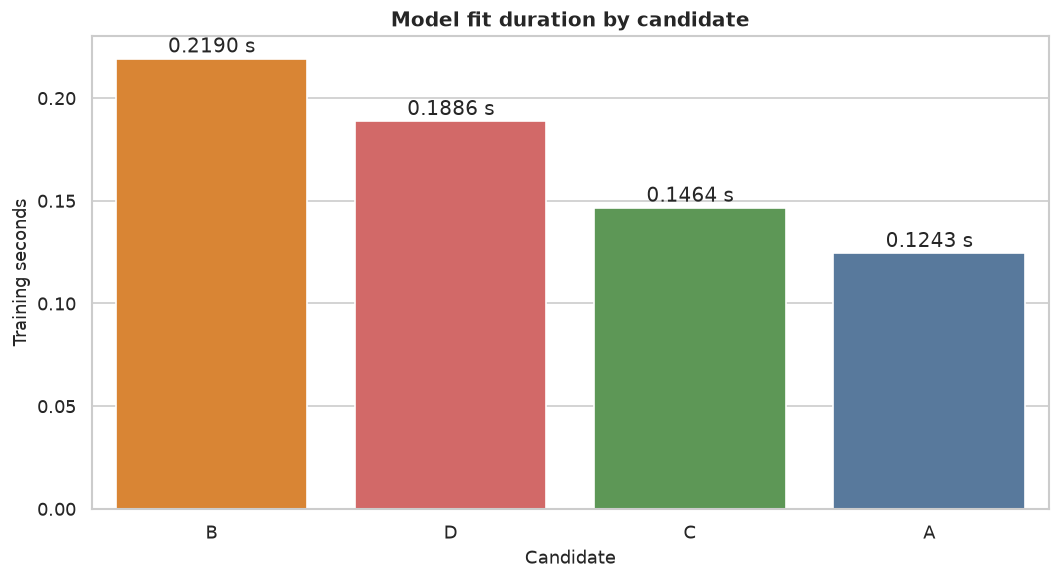

In [41]:
fig, ax = plt.subplots(figsize=(9, 5))
training_plot = comparison.sort_values("training_seconds", ascending=False)

sns.barplot(
    data=training_plot,
    x="candidate_id",
    y="training_seconds",
    hue="candidate_id",
    palette=CANDIDATE_COLORS,
    legend=False,
    ax=ax,
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f s", padding=1)

ax.set(
    title="Model fit duration by candidate",
    xlabel="Candidate",
    ylabel="Training seconds",
)
fig.tight_layout()
fig.savefig(REPORT_ROOT / "training_seconds.png", bbox_inches="tight")
plt.show()


### Insight từ thời gian huấn luyện

Cả bốn model đều fit dưới **0.22 giây**. A nhanh nhất (0.1243 giây), B chậm nhất (0.2190 giây), còn D mất 0.1886 giây. Chênh lệch tuyệt đối dưới 0.1 giây là không đáng kể ở quy mô hiện tại, nên chất lượng phát hiện và tải cảnh báo mới là yếu tố quyết định. Cần benchmark lại khi dữ liệu tăng mạnh vì thời gian của XGBoost không nhất thiết scale giống Logistic Regression.

## 10. Áp dụng quy tắc chọn candidate

Quy tắc chọn model được áp dụng theo thứ tự: (1) precision ≥ 10%, (2) recall cao nhất trong tolerance 0.001, (3) PR-AUC cao nhất trong tolerance 0.01, rồi (4) alert rate và training time thấp hơn. Chỉ ưu tiên Logistic Regression đơn giản hơn khi nó vẫn nằm trong tolerance PR-AUC đã khai báo.


In [ ]:
MIN_PRECISION = 0.10
RECALL_TOLERANCE = 0.001
PR_AUC_TOLERANCE = 0.01

Độ ưu tiên trên phản ánh bài toán fraud hiện tại: trước hết không để precision thấp hơn mức đội vận hành chấp nhận, sau đó giảm false negative, rồi mới tối ưu chất lượng ranking và số lượng alert. Tolerance tránh chọn model phức tạp chỉ vì một chênh lệch rất nhỏ có thể do nhiễu validation.


In [42]:
MIN_PRECISION = 0.10
RECALL_TOLERANCE = 0.001
PR_AUC_TOLERANCE = 0.01


def select_validation_candidate(frame: pd.DataFrame) -> tuple[pd.Series, list[str]]:
    reasons: list[str] = []

    eligible = frame.loc[
        frame["validation_precision"] >= MIN_PRECISION
    ].copy()
    if eligible.empty:
        raise RuntimeError("No candidate satisfies minimum validation precision")
    reasons.append(
        f"{len(eligible)}/4 candidates satisfy precision >= {MIN_PRECISION:.0%}."
    )

    best_recall = float(eligible["validation_recall"].max())
    recall_pool = eligible.loc[
        eligible["validation_recall"] >= best_recall - RECALL_TOLERANCE
    ].copy()
    reasons.append(
        "Kept candidates within "
        f"{RECALL_TOLERANCE:.3f} of best recall ({best_recall:.4f})."
    )

    best_pr_auc = float(recall_pool["validation_pr_auc"].max())
    pr_auc_pool = recall_pool.loc[
        recall_pool["validation_pr_auc"] >= best_pr_auc - PR_AUC_TOLERANCE
    ].copy()
    reasons.append(
        "Kept candidates within "
        f"{PR_AUC_TOLERANCE:.3f} of best PR-AUC ({best_pr_auc:.4f})."
    )

    ranked = pr_auc_pool.sort_values(
        [
            "validation_alert_rate",
            "training_seconds",
            "candidate_id",
        ],
        ascending=[True, True, True],
    )
    winner = ranked.iloc[0]

    logistic_alternative = pr_auc_pool.loc[
        pr_auc_pool["model"] == "logistic_regression"
    ].sort_values(
        ["validation_alert_rate", "training_seconds", "candidate_id"]
    )
    if winner["model"] == "xgboost" and not logistic_alternative.empty:
        winner = logistic_alternative.iloc[0]
        reasons.append(
            "XGBoost and Logistic remained inside the declared PR-AUC tolerance; "
            "selected Logistic Regression as the simpler model."
        )
    else:
        reasons.append(
            "Selected the lowest alert rate after recall and PR-AUC filtering."
        )

    return winner, reasons


winner, selection_reasons = select_validation_candidate(comparison)

display(
    comparison.sort_values(
        [
            "validation_precision",
            "validation_recall",
            "validation_pr_auc",
            "validation_alert_rate",
        ],
        ascending=[False, False, False, True],
    )[DISPLAY_COLUMNS]
)

print("Selected candidate:", winner["candidate_id"])
for reason in selection_reasons:
    print("-", reason)


,candidate_id,model_label,feature_set,validation_pr_auc,validation_roc_auc,validation_precision,validation_recall,validation_f1,validation_alert_rate,threshold,best_iteration,training_seconds
3,D,XGBoost,balance,0.9556,0.9985,0.1014,1.0000,0.1842,0.1235,0.2171,20.0000,0.1886
2,C,Logistic Regression,balance,0.8484,0.9986,0.1000,1.0000,0.1818,0.1253,0.0083,NaN,0.1464
1,B,XGBoost,baseline,0.7560,0.9934,0.1000,1.0000,0.1818,0.1253,0.0091,159.0000,0.2190
0,A,Logistic Regression,baseline,0.5661,0.9323,0.1000,0.9286,0.1806,0.1164,0.0740,NaN,0.1243


Selected candidate: D
- 4/4 candidates satisfy precision >= 10%.
- Kept candidates within 0.001 of best recall (1.0000).
- Kept candidates within 0.010 of best PR-AUC (0.9556).
- Selected the lowest alert rate after recall and PR-AUC filtering.


## Kết luận

**Chọn candidate D — XGBoost với bộ feature balance — để chuyển sang bước đánh giá tiếp theo.**

D thỏa precision tối thiểu, bắt đủ 14/14 fraud trên validation, có PR-AUC cao nhất (0.9556) và alert rate 12.35%. Candidate Logistic tốt nhất là C có cùng recall nhưng PR-AUC thấp hơn D **0.1072**, vượt xa tolerance 0.01; vì vậy quy tắc ưu tiên model đơn giản không được kích hoạt.

Kết luận quan trọng nhất về feature là: các biến mô tả thay đổi và tính nhất quán số dư tạo ra cải thiện rõ rệt cho cả hai họ model. Tuy nhiên, kết quả vẫn có độ bất định cao do validation chỉ có 14 fraud. Candidate D mới là **model được đề xuất trên validation**, chưa phải bằng chứng sẵn sàng production; test phải tiếp tục được giữ khóa cho lần đánh giá cuối và cần kiểm tra thêm calibration, stability theo thời gian, chi phí review cảnh báo và drift.
